# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

**Jaya Jaya Institut — Sistem Deteksi Dini Mahasiswa Berisiko Dropout**

Jaya Jaya Institut adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000 dan telah
mencetak banyak lulusan dengan reputasi sangat baik. Di balik itu, institut menghadapi masalah
serius: **banyak mahasiswa tidak menyelesaikan pendidikannya alias dropout**. Notebook ini
menjalankan seluruh tahapan proyek data science — dari *business understanding* sampai
*deployment* — untuk membantu institut mendeteksi mahasiswa berisiko dropout sedini mungkin
sehingga dapat diberi bimbingan khusus.

- Nama: Nafiul Irsad
- Email: nafiulirsad@gmail.com
- Id Dicoding: nafiulirsad

## Business Understanding

Jaya Jaya Institut memiliki data historis 4.424 mahasiswa lengkap dengan profil demografi,
riwayat pendaftaran, kondisi keuangan, serta performa akademik dua semester pertama. Dari
seluruh mahasiswa tersebut, **1.421 orang (32,12%) berakhir dengan status dropout** — hampir
satu dari tiga mahasiswa. Angka ini jauh di atas rata-rata dropout perguruan tinggi yang wajar
(± 10-15%) dan berdampak langsung pada pendapatan institusi, rasio kelulusan, serta reputasi
akademik yang selama ini dijaga.

Persoalan utamanya bukan sekadar besarnya angka, melainkan **institut baru mengetahui seorang
mahasiswa dropout setelah kejadiannya berlangsung**. Padahal jejak masalahnya — tunggakan UKT,
mata kuliah yang tidak lulus, nilai semester yang jatuh — sudah terlihat jauh sebelum mahasiswa
benar-benar berhenti kuliah.

### Permasalahan Bisnis

1. **Tingkat dropout mencapai 32,12%** (1.421 dari 4.424 mahasiswa) sehingga separuh lebih dari
   potensi pendapatan dan target kelulusan tidak tercapai.
2. **Faktor pendorong dropout belum teridentifikasi secara kuantitatif.** Manajemen belum tahu
   variabel mana yang paling menentukan dan segmen mahasiswa mana yang paling rentan.
3. **Belum ada mekanisme deteksi dini.** Tidak ada sistem yang bisa menandai mahasiswa berisiko
   sebelum mereka berhenti kuliah, sehingga bimbingan khusus selalu terlambat diberikan.
4. **Tidak ada alat monitoring.** Data mahasiswa masih berupa berkas mentah; bagian akademik
   tidak dapat memantau performa mahasiswa per program studi, jalur masuk, atau status keuangan.
5. **794 mahasiswa berstatus masih aktif (Enrolled) belum terpantau.** Kondisi kelompok ini
   tidak diketahui sehingga institut tidak tahu siapa yang perlu diintervensi semester ini.

### Cakupan Proyek

| Tahap | Keluaran |
|---|---|
| Data Understanding | Profil kualitas data 4.424 baris × 37 kolom, kamus data, deteksi nilai kosong & duplikat |
| Exploratory Data Analysis | Dropout rate per segmen akademik, keuangan, demografi, program studi, dan jalur masuk |
| Data Preparation | Binarisasi target, *feature engineering* rasio kelulusan & tren nilai, tabel analitik |
| Modeling | Perbandingan 3 algoritma + *hyperparameter tuning* dengan `RandomizedSearchCV` |
| Evaluation | ROC-AUC, PR-AUC, recall, F1/F2, pemilihan ambang operasional, *permutation importance* |
| Deployment | Model `.joblib`, prototipe **Streamlit** (Streamlit Community Cloud), **business dashboard Metabase** di atas PostgreSQL |

### Tujuan Proyek

1. Mengidentifikasi faktor-faktor yang paling menentukan dropout mahasiswa.
2. Membangun model machine learning yang mampu memprediksi risiko dropout dengan **recall tinggi**
   (lebih baik menandai mahasiswa yang ternyata aman daripada melewatkan yang benar-benar berisiko).
3. Menyediakan **business dashboard** untuk memonitor performa mahasiswa secara berkelanjutan.
4. Menyediakan **prototipe aplikasi** yang bisa langsung dipakai staf akademik tanpa perlu menulis kode.

## Persiapan

### Menyiapkan library yang dibutuhkan

Seluruh analisis memakai *stack* Python standar untuk data science. Modul lokal
`preprocessing.py` menyimpan kamus label, fungsi *feature engineering*, dan definisi fitur
model — modul yang sama dipakai oleh aplikasi Streamlit sehingga transformasi saat pelatihan
dan saat inferensi dijamin identik (mencegah *training-serving skew*).

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report, confusion_matrix,
    f1_score, fbeta_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import loguniform, randint, uniform

sys.path.append(str(Path.cwd()))
import preprocessing as pp

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Palet warna konsisten untuk seluruh visualisasi:
#   merah-oranye  -> metrik dropout (hal yang ingin ditekan)
#   biru          -> metrik netral / pembanding
#   hijau         -> kondisi aman
DROPOUT = "#E4572E"
NEUTRAL = "#2E86AB"
SAFE = "#2E9E5B"
ACCENT = "#F2A541"
GREY = "#8A939B"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#CCCCCC", "grid.color": "#EAEAEA", "font.size": 10,
})

ASSETS = Path("assets"); ASSETS.mkdir(exist_ok=True)
MODEL_DIR = Path("model"); MODEL_DIR.mkdir(exist_ok=True)
DATA_DIR = Path("data")

print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

pandas 3.0.5 | numpy 2.5.2
scikit-learn 1.9.0


### Menyiapkan data yang akan digunakan

Sumber data: **[Students' Performance — Dicoding Academy](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/README.md)**
(turunan dari *Predict Students' Dropout and Academic Success*, UCI Machine Learning Repository).
Berkas mentah memakai pemisah titik koma (`;`) dan sudah disalin ke `data/data.csv` agar
notebook dapat dijalankan ulang tanpa koneksi internet.

In [2]:
df = pd.read_csv(DATA_DIR / "data.csv", sep=";")

print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]:,}")
df.head()

Jumlah baris  : 4,424
Jumlah kolom  : 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Penjelasan tahapan.** Data berhasil dimuat: **4.424 baris × 37 kolom**. Satu baris mewakili
satu mahasiswa pada saat pendaftaran ditambah rekam jejak akademik dua semester pertama, dan
kolom `Status` berisi hasil akhir studi mahasiswa tersebut.

## Data Understanding

Tahap ini menjawab tiga pertanyaan: *apa isi datanya*, *seberapa bersih datanya*, dan
*bagaimana sebaran targetnya*.

In [3]:
print("=== Tipe data & jumlah nilai non-null ===")
df.info()

print("\n=== Pemeriksaan kualitas data ===")
print(f"Total nilai kosong (missing) : {df.isna().sum().sum()}")
print(f"Baris duplikat               : {df.duplicated().sum()}")
print(f"Kolom konstan (1 nilai unik) : {[c for c in df.columns if df[c].nunique() == 1]}")

=== Tipe data & jumlah nilai non-null ===
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification           

**Insight kualitas data.** Dataset dalam kondisi sangat bersih: **tidak ada satu pun nilai
kosong, tidak ada baris duplikat, dan tidak ada kolom konstan**. Seluruh 36 fitur bertipe
numerik (`int64`/`float64`) dan hanya kolom target `Status` yang bertipe teks. Perlu dicatat
bahwa tipe numerik di sini **menyesatkan**: kolom seperti `Course`, `Application_mode`, dan
`Marital_status` sebenarnya adalah **kode kategorikal**, bukan besaran yang bisa dijumlahkan.
Kesalahan memperlakukannya sebagai numerik akan membuat model mengasumsikan urutan yang tidak
ada — hal ini ditangani pada tahap Data Preparation dengan *one-hot encoding*.

In [4]:
print("=== Statistik deskriptif fitur numerik utama ===")
kolom_ringkas = [
    "Age_at_enrollment", "Admission_grade", "Previous_qualification_grade",
    "Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_approved", "Curricular_units_2nd_sem_grade",
    "Unemployment_rate", "Inflation_rate", "GDP",
]
df[kolom_ringkas].describe().T.round(2)

=== Statistik deskriptif fitur numerik utama ===


,count,mean,std,min,25%,50%,75%,max
Age_at_enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Admission_grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Curricular_units_1st_sem_enrolled,4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular_units_1st_sem_approved,4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular_units_1st_sem_grade,4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular_units_2nd_sem_enrolled,4424.0,6.23,2.20,0.00,5.00,6.00,7.00,23.00
Curricular_units_2nd_sem_approved,4424.0,4.44,3.01,0.00,2.00,5.00,6.00,20.00
Curricular_units_2nd_sem_grade,4424.0,10.23,5.21,0.00,10.75,12.20,13.33,18.57
Unemployment_rate,4424.0,11.57,2.66,7.60,9.40,11.10,13.90,16.20


**Insight statistik deskriptif.** Usia saat mendaftar berkisar 17-70 tahun dengan median 20
tahun — artinya ada kelompok mahasiswa non-tradisional (usia lanjut) yang perlu diperiksa
terpisah. Nilai masuk (`Admission_grade`) memakai skala 0-200 dengan rata-rata ± 127.
Yang paling penting: **nilai semester (`..._sem_grade`) memiliki nilai minimum 0**, dan angka 0
di sini bukan berarti "nilai jelek" melainkan **mahasiswa tidak menempuh evaluasi sama sekali** —
sinyal keterlibatan (*engagement*) yang sangat kuat dan akan dipakai sebagai fitur turunan.

### Kamus data

Ke-37 kolom dapat dikelompokkan menjadi lima kelompok berikut.

| Kelompok | Kolom | Keterangan |
|---|---|---|
| **Demografi** | `Marital_status`, `Gender`, `Age_at_enrollment`, `Nacionality`, `International`, `Displaced`, `Educational_special_needs` | Profil pribadi mahasiswa. Kolom berkode: 1 = laki-laki / 0 = perempuan pada `Gender`. |
| **Latar belakang keluarga** | `Mothers_qualification`, `Fathers_qualification`, `Mothers_occupation`, `Fathers_occupation` | Kode pendidikan & pekerjaan orang tua. |
| **Pendaftaran** | `Application_mode`, `Application_order`, `Course`, `Daytime_evening_attendance`, `Previous_qualification`, `Previous_qualification_grade`, `Admission_grade` | Jalur masuk, program studi, dan nilai seleksi. |
| **Keuangan** | `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder` | Status tunggakan, kelunasan UKT, dan beasiswa. |
| **Akademik semester 1 & 2** | `Curricular_units_{1st,2nd}_sem_{credited,enrolled,evaluations,approved,grade,without_evaluations}` | Jumlah SKS diambil, dievaluasi, lulus, serta nilai rata-rata per semester. |
| **Makroekonomi** | `Unemployment_rate`, `Inflation_rate`, `GDP` | Kondisi ekonomi pada tahun angkatan. |
| **Target** | `Status` | `Dropout`, `Enrolled` (masih aktif), atau `Graduate` (lulus). |

          Jumlah  Persentase (%)
Status                          
Graduate    2209           49.93
Dropout     1421           32.12
Enrolled     794           17.95


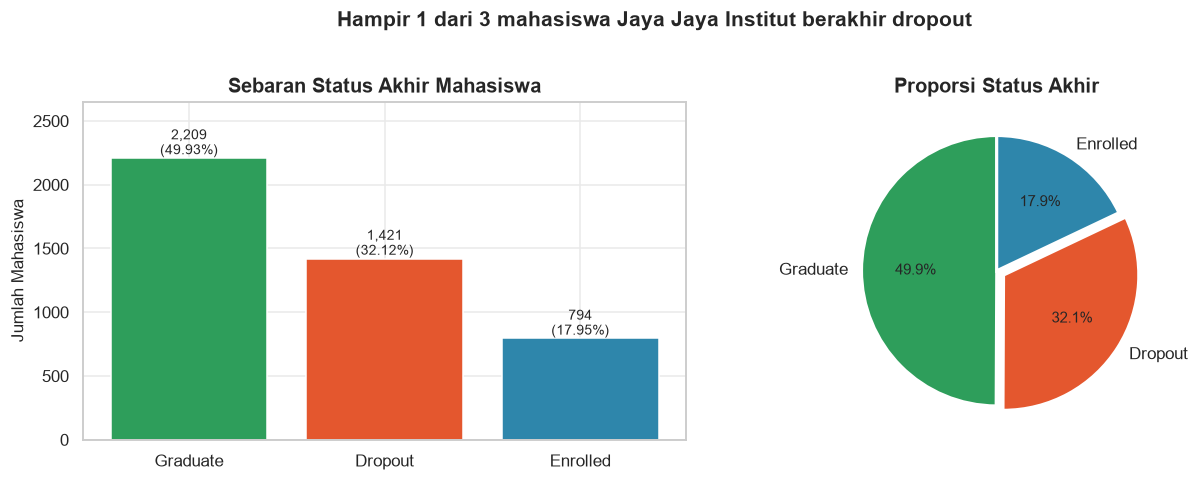

In [5]:
status_count = df["Status"].value_counts()
status_pct = (status_count / len(df) * 100).round(2)
ringkasan_status = pd.DataFrame({"Jumlah": status_count, "Persentase (%)": status_pct})
print(ringkasan_status.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
warna = {"Graduate": SAFE, "Dropout": DROPOUT, "Enrolled": NEUTRAL}
urut = ["Graduate", "Dropout", "Enrolled"]

bars = axes[0].bar(urut, [status_count[s] for s in urut], color=[warna[s] for s in urut])
for b, s in zip(bars, urut):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 30,
                 f"{status_count[s]:,}\n({status_pct[s]}%)", ha="center", fontsize=9)
axes[0].set_title("Sebaran Status Akhir Mahasiswa")
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].set_ylim(0, status_count.max() * 1.2)

axes[1].pie([status_count[s] for s in urut], labels=urut, colors=[warna[s] for s in urut],
            autopct="%1.1f%%", startangle=90, explode=(0, 0.06, 0),
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporsi Status Akhir")

fig.suptitle("Hampir 1 dari 3 mahasiswa Jaya Jaya Institut berakhir dropout",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(ASSETS / "01_sebaran_status.png")
plt.show()

**Insight sebaran target.** Dari 4.424 mahasiswa: **2.209 lulus (49,93%), 1.421 dropout
(32,12%), dan 794 masih aktif kuliah (17,95%)**. Angka dropout 32,12% inilah masalah bisnis yang
harus dipecahkan. Sebarannya juga **tidak seimbang** (32% berbanding 68%), sehingga akurasi
bukan metrik yang tepat — model yang selalu menebak "tidak dropout" sudah mendapat akurasi 68%
tanpa berguna sama sekali. Karena itu evaluasi memakai **ROC-AUC, PR-AUC, dan recall**.

### Exploratory Data Analysis

Pertanyaan yang dijawab pada tahap ini: **segmen mahasiswa mana yang dropout-nya di atas
rata-rata institut (32,12%)?** Setiap grafik memakai satu garis pembanding putus-putus pada
angka rata-rata tersebut sehingga pembaca langsung dapat menilai segmen mana yang bermasalah,
bukan sekadar melihat tinggi-rendahnya batang.

Untuk keperluan analisis, kolom `Status` diringkas menjadi indikator biner `is_dropout`
(1 = dropout, 0 = lulus atau masih aktif) dan kode-kode numerik diterjemahkan menjadi label
yang terbaca lewat modul `preprocessing.py`.

In [6]:
# Feature engineering + penerjemahan kode menjadi label yang terbaca manusia
eda = pp.add_readable_labels(pp.engineer_features(df))
eda["is_dropout"] = (eda["Status"] == pp.POSITIVE_CLASS).astype(int)

BASELINE = eda["is_dropout"].mean() * 100
print(f"Dropout rate rata-rata institut: {BASELINE:.2f}%")

def dropout_rate(kolom, urutan=None, min_n=1):
    """Hitung dropout rate (%) dan jumlah mahasiswa untuk setiap kategori pada `kolom`."""
    g = eda.groupby(kolom, observed=True)["is_dropout"].agg(jumlah="size", rate="mean")
    g["rate"] = g["rate"] * 100
    g = g[g["jumlah"] >= min_n]
    return g.loc[urutan] if urutan else g.sort_values("rate", ascending=False)

def plot_rate(ax, tabel, judul, xlabel="", horizontal=False, warna=DROPOUT):
    """Gambar dropout rate per kategori beserta garis pembanding rata-rata institut."""
    label = [f"{i}\n(n={int(r.jumlah)})" if not horizontal else f"{i} (n={int(r.jumlah)})"
             for i, r in tabel.iterrows()]
    if horizontal:
        ax.barh(label, tabel["rate"], color=warna)
        ax.axvline(BASELINE, color=GREY, ls="--", lw=1.4)
        ax.set_xlabel("Dropout Rate (%)")
        for y, v in enumerate(tabel["rate"]):
            ax.text(v + 0.8, y, f"{v:.1f}%", va="center", fontsize=9)
        ax.set_xlim(0, max(tabel["rate"]) * 1.18)
        ax.invert_yaxis()
    else:
        ax.bar(label, tabel["rate"], color=warna)
        ax.axhline(BASELINE, color=GREY, ls="--", lw=1.4)
        ax.set_ylabel("Dropout Rate (%)")
        for x, v in enumerate(tabel["rate"]):
            ax.text(x, v + 1.2, f"{v:.1f}%", ha="center", fontsize=9)
        ax.set_ylim(0, max(tabel["rate"]) * 1.22)
    ax.set_title(judul)
    ax.set_xlabel(xlabel) if not horizontal else None
    ax.grid(axis="x" if horizontal else "y", alpha=.4)
    ax.grid(axis="y" if horizontal else "x", visible=False)

Dropout rate rata-rata institut: 32.12%


#### 1. Faktor keuangan

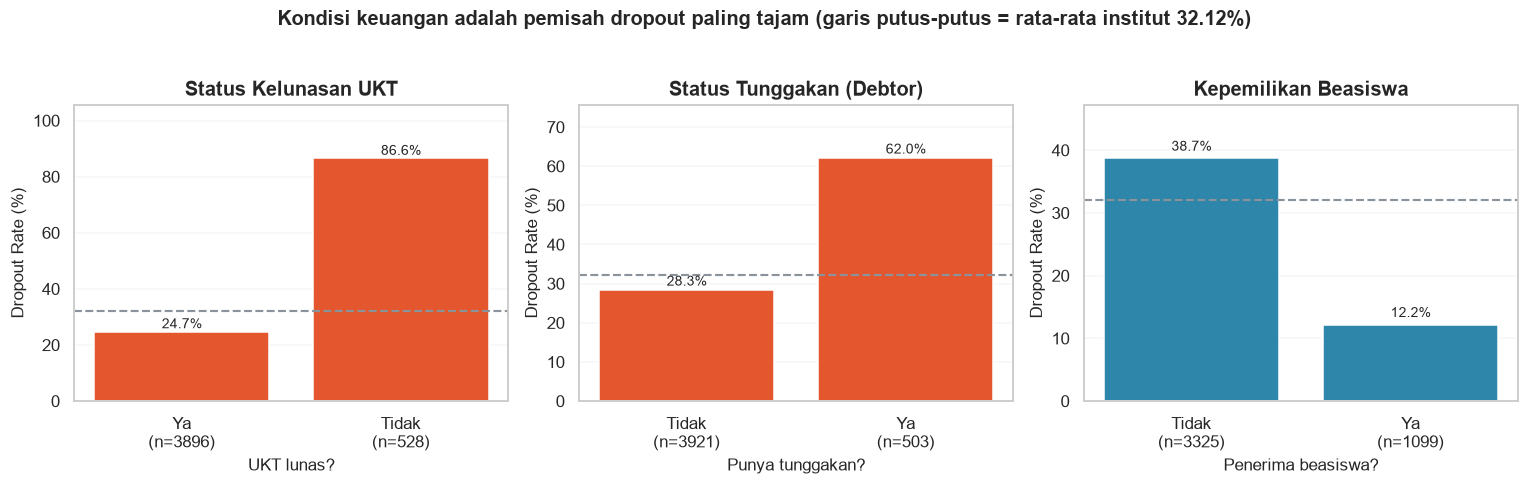

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
plot_rate(axes[0], dropout_rate("tuition_fees_up_to_date_label", ["Ya", "Tidak"]),
          "Status Kelunasan UKT", "UKT lunas?")
plot_rate(axes[1], dropout_rate("debtor_label", ["Tidak", "Ya"]),
          "Status Tunggakan (Debtor)", "Punya tunggakan?")
plot_rate(axes[2], dropout_rate("scholarship_holder_label", ["Tidak", "Ya"]),
          "Kepemilikan Beasiswa", "Penerima beasiswa?", warna=NEUTRAL)
fig.suptitle("Kondisi keuangan adalah pemisah dropout paling tajam "
             f"(garis putus-putus = rata-rata institut {BASELINE:.2f}%)",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout()
fig.savefig(ASSETS / "02_faktor_keuangan.png")
plt.show()

**Insight faktor keuangan — sinyal paling tajam di seluruh dataset.**

- Mahasiswa yang **UKT-nya belum lunas dropout sebesar 86,55%**, dibanding hanya **24,74%** pada
  yang lunas. Selisih **3,5 kali lipat** ini menjadikan `Tuition_fees_up_to_date` prediktor
  tunggal terkuat: dari 528 mahasiswa yang menunggak UKT, 457 di antaranya berakhir dropout.
- Mahasiswa dengan status **debtor dropout 62,03%** versus 28,28% pada yang tidak menunggak.
- **Beasiswa bekerja sebagai pelindung**: penerima beasiswa hanya dropout **12,19%**, sepertiga
  dari angka non-penerima (38,71%).

Implikasi bisnis langsung: **masalah keuangan lebih menentukan daripada kemampuan akademik**.
Tunggakan UKT bukan sekadar urusan administrasi, melainkan alarm dropout yang datanya sudah
dimiliki institut setiap bulan.

#### 2. Faktor demografi dan pola kuliah

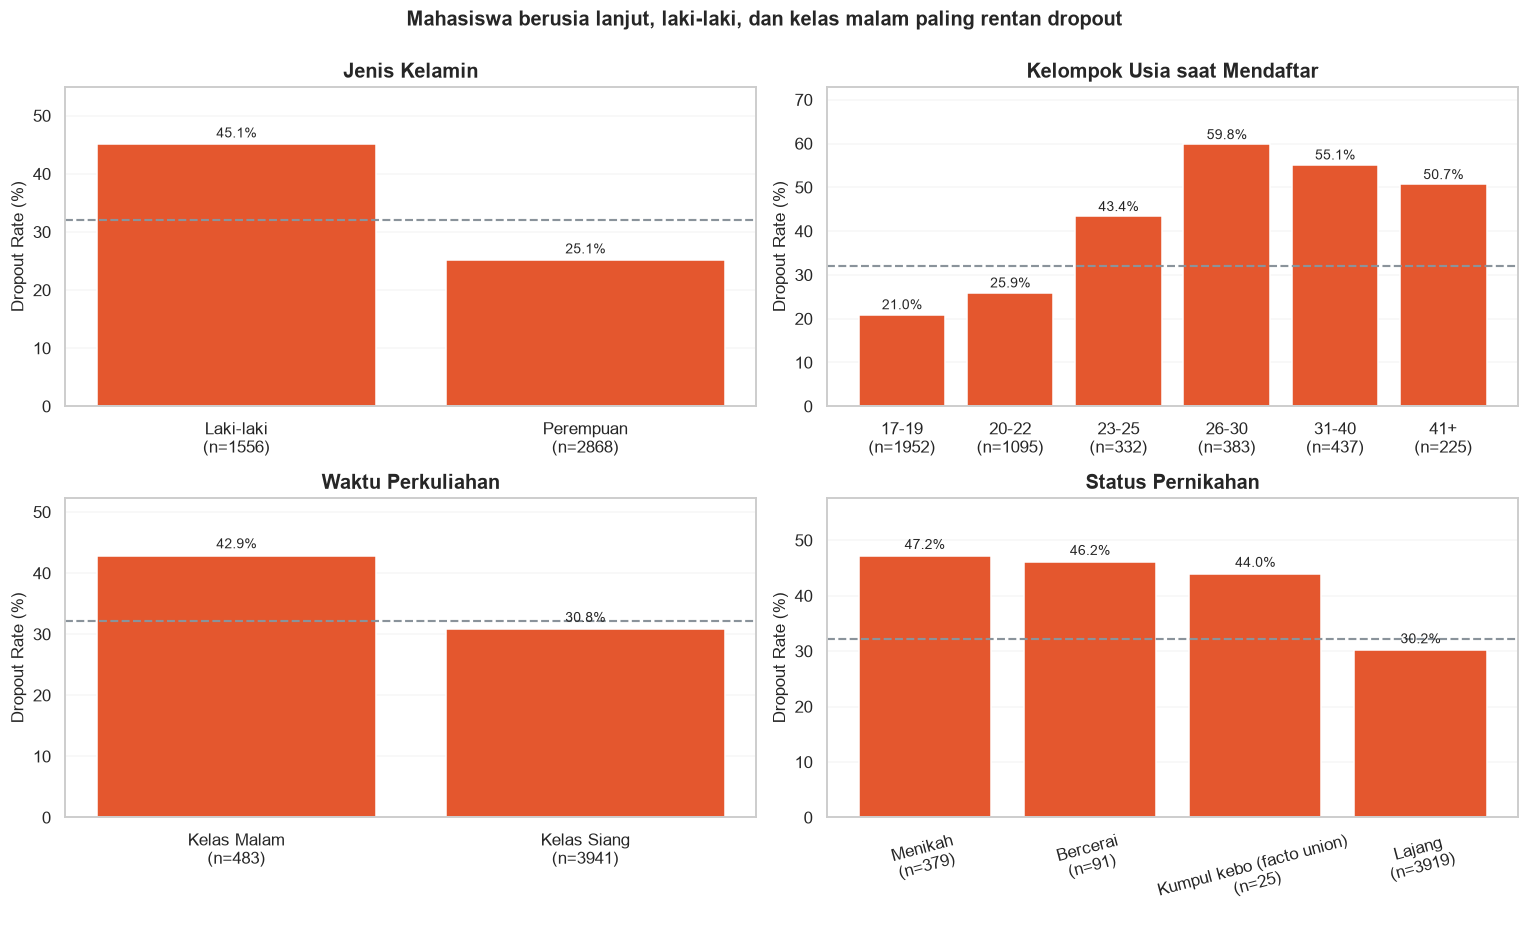

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.4))
plot_rate(axes[0][0], dropout_rate("jenis_kelamin"), "Jenis Kelamin")
plot_rate(axes[0][1], dropout_rate("kelompok_usia", ["17-19", "20-22", "23-25", "26-30", "31-40", "41+"]),
          "Kelompok Usia saat Mendaftar")
plot_rate(axes[1][0], dropout_rate("waktu_kuliah"), "Waktu Perkuliahan")
plot_rate(axes[1][1], dropout_rate("status_pernikahan", min_n=20), "Status Pernikahan")
axes[1][1].tick_params(axis="x", labelrotation=15)
fig.suptitle("Mahasiswa berusia lanjut, laki-laki, dan kelas malam paling rentan dropout",
             fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(ASSETS / "03_faktor_demografi.png")
plt.show()

**Insight faktor demografi.**

- **Usia adalah gradien yang jelas.** Dropout naik konsisten dari **20,95% (usia 17-19)** menjadi
  **43,37% (23-25)** dan memuncak pada **59,79% (26-30)**. Mahasiswa yang mendaftar pada usia
  lanjut umumnya sudah bekerja atau berkeluarga sehingga kuliah bersaing dengan kewajiban lain.
- **Laki-laki dropout 45,05%**, hampir dua kali lipat perempuan (**25,10%**).
- **Kelas malam dropout 42,86%** versus kelas siang 30,80% — konsisten dengan temuan usia, karena
  kelas malam banyak diisi mahasiswa yang bekerja.
- **Mahasiswa menikah dropout 47,23%** dibanding lajang 30,21%.

Keempat temuan ini mengarah ke satu profil yang sama: **mahasiswa dengan beban hidup di luar
kampus**. Program pendampingan tidak cukup bersifat akademik — perlu fleksibilitas jadwal.

#### 3. Performa akademik dua semester pertama

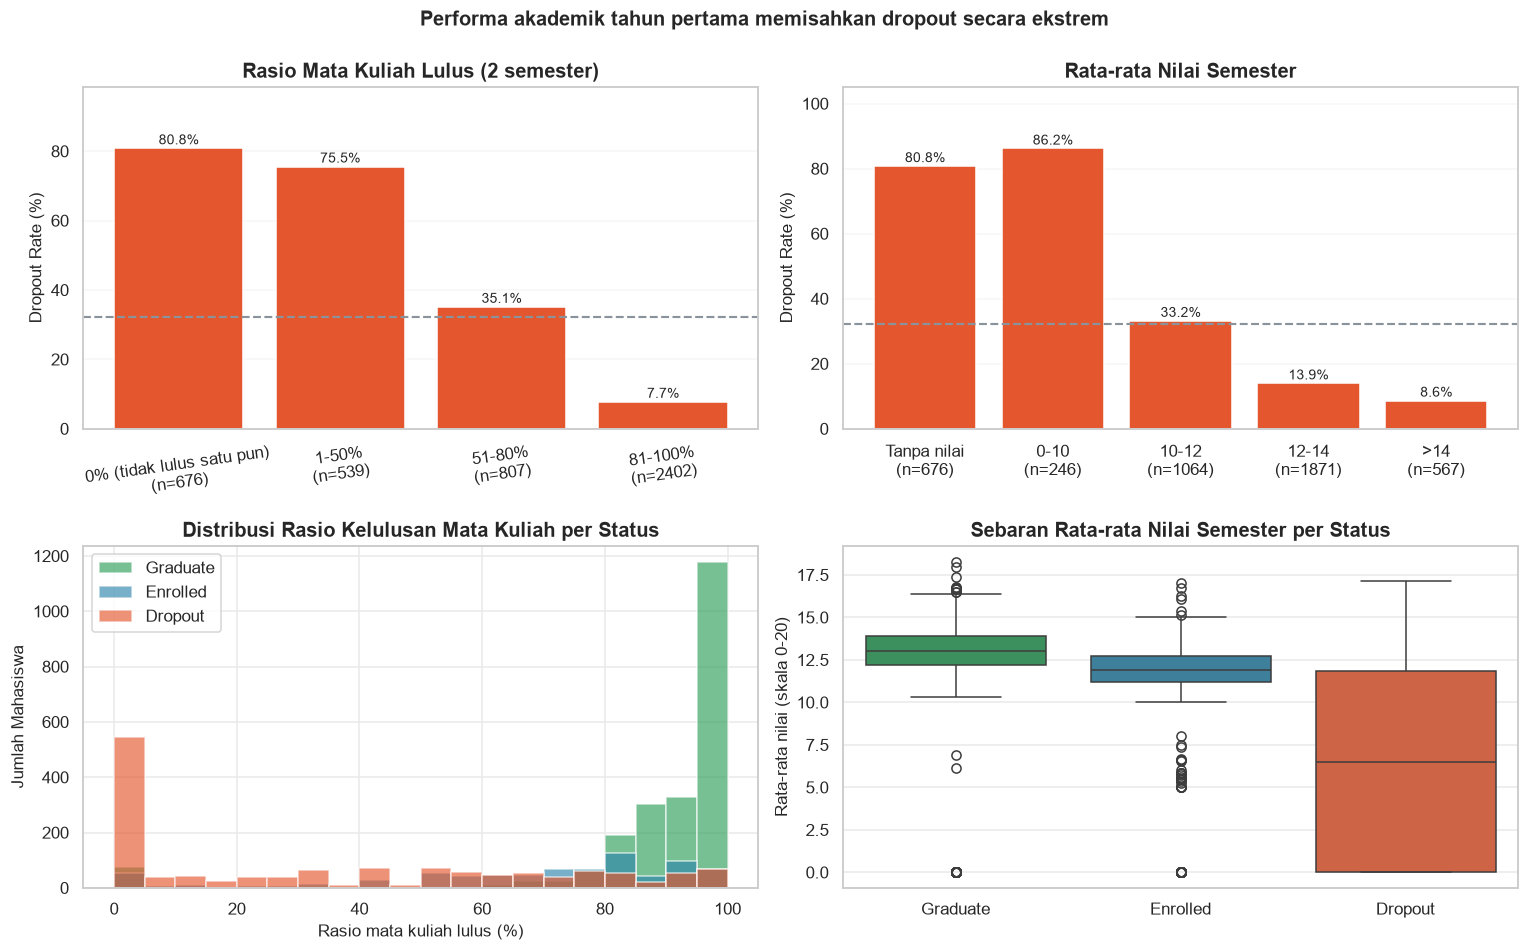

          approval_rate_total  avg_grade  total_approved
Status                                                  
Dropout                 0.339      6.578           4.492
Enrolled                0.669     11.121           8.377
Graduate                0.902     12.670          12.409


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.6))

plot_rate(axes[0][0], dropout_rate("band_kelulusan_sks",
          ["0% (tidak lulus satu pun)", "1-50%", "51-80%", "81-100%"]),
          "Rasio Mata Kuliah Lulus (2 semester)")
axes[0][0].tick_params(axis="x", labelrotation=8)

plot_rate(axes[0][1], dropout_rate("band_nilai_semester",
          ["Tanpa nilai", "0-10", "10-12", "12-14", ">14"]),
          "Rata-rata Nilai Semester")

for status, warna in [("Graduate", SAFE), ("Enrolled", NEUTRAL), ("Dropout", DROPOUT)]:
    sub = eda[eda["Status"] == status]
    axes[1][0].hist(sub["approval_rate_total"] * 100, bins=20, alpha=.65, label=status, color=warna)
axes[1][0].set_title("Distribusi Rasio Kelulusan Mata Kuliah per Status")
axes[1][0].set_xlabel("Rasio mata kuliah lulus (%)"); axes[1][0].set_ylabel("Jumlah Mahasiswa")
axes[1][0].legend()

sns.boxplot(data=eda, x="Status", y="avg_grade", order=["Graduate", "Enrolled", "Dropout"],
            palette={"Graduate": SAFE, "Enrolled": NEUTRAL, "Dropout": DROPOUT}, ax=axes[1][1])
axes[1][1].set_title("Sebaran Rata-rata Nilai Semester per Status")
axes[1][1].set_ylabel("Rata-rata nilai (skala 0-20)"); axes[1][1].set_xlabel("")

fig.suptitle("Performa akademik tahun pertama memisahkan dropout secara ekstrem",
             fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(ASSETS / "04_performa_akademik.png")
plt.show()

print(eda.groupby("Status")[["approval_rate_total", "avg_grade", "total_approved"]]
        .mean().round(3).to_string())

**Insight performa akademik — pemisah terkuat kedua.**

- Mahasiswa yang **tidak lulus satu pun mata kuliah dropout 80,77%** (676 orang), sementara yang
  lulus 81-100% mata kuliah hanya dropout **7,70%** (2.402 orang). Rentangnya lebih dari
  **10 kali lipat**.
- Pola yang sama terlihat pada nilai: rata-rata nilai di bawah 10 → dropout **86,18%**;
  di atas 14 → dropout **8,64%**.
- Rata-rata rasio kelulusan mata kuliah: **Graduate 0,90 — Enrolled 0,67 — Dropout 0,34**.
  Kelompok Enrolled berada persis di tengah, menegaskan bahwa mereka adalah kelompok "abu-abu"
  yang paling membutuhkan pemantauan.
- Histogram memperlihatkan **penumpukan besar mahasiswa dropout tepat di rasio 0%** — kelompok
  yang mendaftar lalu praktis tidak pernah mengikuti evaluasi. Ini bukan kegagalan akademik
  bertahap, melainkan **putus keterlibatan sejak awal** yang seharusnya terdeteksi di minggu-minggu
  pertama perkuliahan.

#### 4. Program studi dan jalur masuk

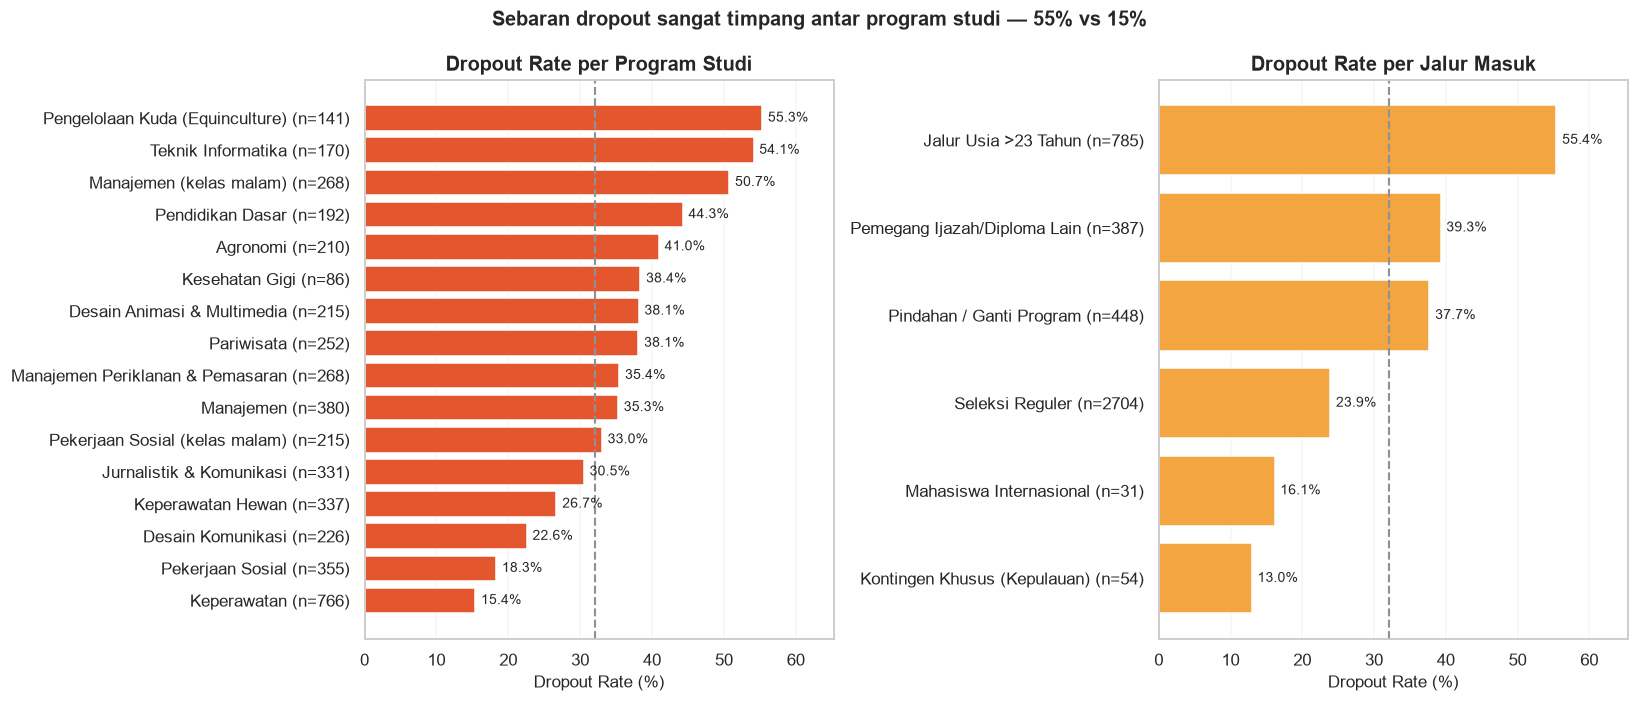

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))
plot_rate(axes[0], dropout_rate("program_studi", min_n=30), "Dropout Rate per Program Studi",
          horizontal=True)
plot_rate(axes[1], dropout_rate("jalur_masuk", min_n=30), "Dropout Rate per Jalur Masuk",
          horizontal=True, warna=ACCENT)
fig.suptitle("Sebaran dropout sangat timpang antar program studi — 55% vs 15%",
             fontsize=13, fontweight="bold", y=0.99)
fig.tight_layout()
fig.savefig(ASSETS / "05_program_studi.png")
plt.show()

**Insight program studi & jalur masuk.**

- Selisih antar program studi sangat lebar: **Pengelolaan Kuda (55,32%)**, **Teknik Informatika
  (54,12%)**, dan **Manajemen kelas malam (50,75%)** berada di ujung atas, sedangkan
  **Keperawatan hanya 15,40%** dengan populasi terbesar (766 mahasiswa) dan **Pekerjaan Sosial
  18,31%**. Artinya masalah dropout **tidak merata** dan intervensi paling efisien bila
  difokuskan pada 4-5 program studi teratas.
- Dari sisi jalur masuk, **jalur usia di atas 23 tahun dropout 55,41%** (785 mahasiswa) dan
  **pemegang ijazah/diploma lain 61,15%**, sementara **seleksi reguler hanya 20,20%** pada fase 1.
  Jalur non-reguler menyumbang risiko yang jauh lebih besar dan layak diberi program orientasi
  khusus sejak awal semester.

#### 5. Korelasi fitur numerik terhadap dropout

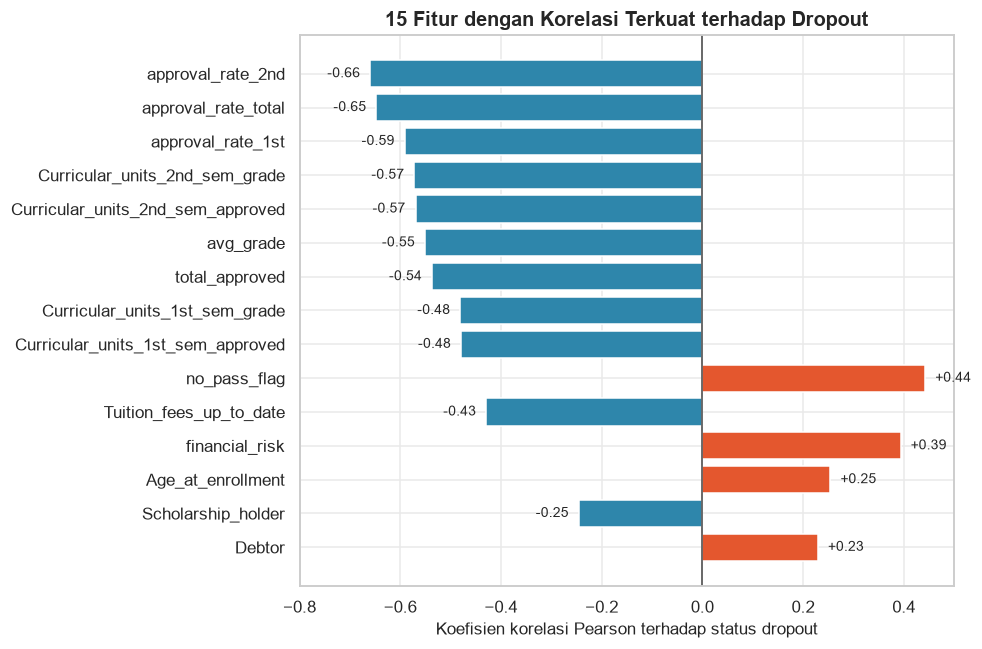

approval_rate_2nd                   -0.659
approval_rate_total                 -0.647
approval_rate_1st                   -0.591
Curricular_units_2nd_sem_grade      -0.572
Curricular_units_2nd_sem_approved   -0.570
avg_grade                           -0.551
total_approved                      -0.537
Curricular_units_1st_sem_grade      -0.481
Curricular_units_1st_sem_approved   -0.479
no_pass_flag                         0.442
Tuition_fees_up_to_date             -0.429
financial_risk                       0.394
Age_at_enrollment                    0.254
Scholarship_holder                  -0.245
Debtor                               0.229


In [11]:
num_cols = eda.select_dtypes(include=[np.number]).columns
korelasi = (eda[num_cols].corr(numeric_only=True)["is_dropout"]
            .drop("is_dropout").sort_values(key=abs, ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
warna_bar = [DROPOUT if v > 0 else NEUTRAL for v in korelasi]
ax.barh(korelasi.index[::-1], korelasi.values[::-1], color=warna_bar[::-1])
ax.axvline(0, color="#444444", lw=1)
for y, v in enumerate(korelasi.values[::-1]):
    ax.text(v + (0.02 if v > 0 else -0.02), y, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9)
ax.set_title("15 Fitur dengan Korelasi Terkuat terhadap Dropout")
ax.set_xlabel("Koefisien korelasi Pearson terhadap status dropout")
ax.set_xlim(-0.8, 0.5)
fig.tight_layout()
fig.savefig(ASSETS / "06_korelasi.png")
plt.show()

print(korelasi.round(3).to_string())

**Insight korelasi.** Peringkat korelasi mengonfirmasi seluruh temuan visual sebelumnya:

| Peringkat | Fitur | Korelasi |
|---|---|---|
| 1 | `approval_rate_2nd` (rasio lulus semester 2) | **-0,66** |
| 2 | `approval_rate_total` | -0,65 |
| 3 | `approval_rate_1st` | -0,59 |
| 4 | `Curricular_units_2nd_sem_grade` | -0,57 |
| 5 | `Tuition_fees_up_to_date` | -0,43 |
| 6 | `Age_at_enrollment` | **+0,25** |
| 7 | `Scholarship_holder` | -0,25 |
| 8 | `Debtor` | +0,23 |

Tiga hal penting. Pertama, **semester kedua lebih informatif daripada semester pertama**
(-0,66 vs -0,59) sehingga akhir tahun pertama adalah titik prediksi paling akurat. Kedua,
**fitur turunan hasil rekayasa (`approval_rate_*`) mengungguli fitur mentahnya**, yang
membenarkan langkah feature engineering. Ketiga, **faktor makroekonomi (`Unemployment_rate`,
`Inflation_rate`, `GDP`) tidak masuk 15 besar** — kondisi ekonomi nasional hampir tidak
menjelaskan variasi dropout antar mahasiswa dalam data ini.

## Data Preparation / Preprocessing

Empat keputusan diambil pada tahap ini, masing-masing dengan alasan bisnis yang eksplisit.

**1. Target dibuat biner: `Dropout` versus `Bukan Dropout`.**
Kebutuhan institut adalah menjawab satu pertanyaan operasional — *"mahasiswa ini perlu
diintervensi atau tidak?"* — sehingga masalah tiga kelas (`Dropout`/`Enrolled`/`Graduate`)
disederhanakan menjadi klasifikasi biner. Kelompok `Enrolled` tetap disertakan sebagai kelas
negatif karena pada saat data diambil mereka **memang belum dropout**; dengan begitu proporsi
kelas positif (32,12%) mencerminkan populasi nyata yang akan dihadapi model saat dipakai.

**2. Feature engineering menambah 9 fitur turunan.** Jumlah mata kuliah lulus saja tidak
bermakna tanpa tahu berapa yang diambil; yang informatif adalah **rasionya**. Fitur turunan
yang dibuat: `approval_rate_1st`, `approval_rate_2nd`, `approval_rate_total`, `total_approved`,
`avg_grade`, `grade_trend` (selisih nilai semester 2 - 1), `approval_trend`, `financial_risk`
(gabungan tunggakan + UKT belum lunas), dan `no_pass_flag`.

**3. Fitur dipangkas dari 36 menjadi 29 kolom yang mudah diperoleh.** Kolom pendidikan/pekerjaan
orang tua, kewarganegaraan, dan indikator makroekonomi dibuang karena (a) korelasinya rendah,
(b) sulit dan lambat dikumpulkan staf akademik saat memakai aplikasi. Uji banding menunjukkan
pemangkasan ini **tidak menurunkan performa secara berarti**, sementara formulir aplikasi
menjadi jauh lebih ringkas.

**4. Kode kategorikal di-*one-hot encode*.** `Marital_status`, `Application_mode`, dan `Course`
adalah kode, bukan angka berurutan. Kategori dengan frekuensi di bawah 20 digabung otomatis
(`min_frequency=20`) agar model tidak menghafal kategori langka.

In [12]:
# --- 1. Target biner -------------------------------------------------------------------
data = pp.engineer_features(df)
y = (data[pp.TARGET_COLUMN] == pp.POSITIVE_CLASS).astype(int)
X = data[pp.MODEL_FEATURES]

print(f"Dimensi matriks fitur : {X.shape}")
print(f"Proporsi kelas positif: {y.mean() * 100:.2f}% ({y.sum():,} dropout dari {len(y):,})")
print(f"\nFitur kategorikal ({len(pp.CATEGORICAL_FEATURES)}): {pp.CATEGORICAL_FEATURES}")
print(f"Fitur numerik ({len(pp.NUMERIC_FEATURES)}):")
print("   " + ", ".join(pp.NUMERIC_FEATURES))

# --- 2. Pembagian data -----------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"\nData latih : {X_train.shape[0]:,} baris ({y_train.mean()*100:.2f}% dropout)")
print(f"Data uji   : {X_test.shape[0]:,} baris ({y_test.mean()*100:.2f}% dropout)")

# --- 3. Pipeline preprocessing ---------------------------------------------------------
def buat_preprocessor(scale: bool):
    """One-hot untuk kode kategorikal; penskalaan hanya diperlukan model linier."""
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False),
         pp.CATEGORICAL_FEATURES),
        ("num", StandardScaler() if scale else "passthrough", pp.NUMERIC_FEATURES),
    ])

contoh = buat_preprocessor(False).fit(X_train)
print(f"\nJumlah kolom setelah encoding: {contoh.transform(X_train).shape[1]}")

Dimensi matriks fitur : (4424, 29)
Proporsi kelas positif: 32.12% (1,421 dropout dari 4,424)

Fitur kategorikal (3): ['Marital_status', 'Application_mode', 'Course']
Fitur numerik (26):
   Application_order, Daytime_evening_attendance, Previous_qualification_grade, Admission_grade, Displaced, Debtor, Tuition_fees_up_to_date, Gender, Scholarship_holder, Age_at_enrollment, International, Curricular_units_1st_sem_enrolled, Curricular_units_1st_sem_approved, Curricular_units_1st_sem_grade, Curricular_units_2nd_sem_enrolled, Curricular_units_2nd_sem_approved, Curricular_units_2nd_sem_grade, approval_rate_1st, approval_rate_2nd, approval_rate_total, total_approved, avg_grade, grade_trend, approval_trend, financial_risk, no_pass_flag

Data latih : 3,539 baris (32.13% dropout)
Data uji   : 885 baris (32.09% dropout)

Jumlah kolom setelah encoding: 61


**Penjelasan tahapan.** Data dibagi **80% latih (3.539 baris) / 20% uji (885 baris)** dengan
`stratify=y` sehingga proporsi dropout 32,12% terjaga sama di kedua bagian — penting karena
kelas tidak seimbang. Seluruh transformasi dibungkus dalam `Pipeline` scikit-learn, artinya
*encoder* dan *scaler* hanya belajar dari data latih dan tidak pernah "mengintip" data uji
(mencegah *data leakage*).

## Modeling

Tiga algoritma dengan karakter berbeda diuji sebagai *baseline*, lalu masing-masing disetel
dengan `RandomizedSearchCV`:

| Algoritma | Alasan pemilihan |
|---|---|
| **Logistic Regression** | Cepat, koefisiennya mudah dijelaskan ke manajemen, menjadi tolok ukur dasar. |
| **Random Forest** | Menangkap interaksi non-linier (misal: menunggak **dan** nilai rendah) tanpa banyak penyetelan. |
| **Hist Gradient Boosting** | Boosting modern yang biasanya paling akurat pada data tabular. |

Karena kelas tidak seimbang, model berbasis bobot memakai `class_weight="balanced"` dan
metrik pemilihan model adalah **ROC-AUC dengan validasi silang 5-fold** — bukan akurasi.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

kandidat = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE), True),
    "Random Forest": (
        RandomForestClassifier(n_estimators=400, class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1), False),
    "Hist Gradient Boosting": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE), False),
}

def ukur(nama, pipe, hitung_cv=True):
    """Latih pipeline lalu kumpulkan metrik pada data uji (ambang standar 0,5)."""
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    hasil = {
        "Model": nama,
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "Akurasi": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    }
    if hitung_cv:
        hasil["CV ROC-AUC"] = cross_val_score(pipe, X_train, y_train, cv=cv,
                                              scoring="roc_auc", n_jobs=-1).mean()
    return hasil

baseline = pd.DataFrame([
    ukur(nama, Pipeline([("prep", buat_preprocessor(skala)), ("clf", clf)]))
    for nama, (clf, skala) in kandidat.items()
]).set_index("Model")[["CV ROC-AUC", "ROC-AUC", "PR-AUC", "Akurasi", "Precision", "Recall", "F1"]]

baseline.round(4)

,CV ROC-AUC,ROC-AUC,PR-AUC,Akurasi,Precision,Recall,F1
Model,,,,,,,
Logistic Regression,0.9147,0.9312,0.9002,0.8757,0.7900,0.8345,0.8116
Random Forest,0.9157,0.9270,0.8931,0.8757,0.8085,0.8028,0.8057
Hist Gradient Boosting,0.9066,0.9293,0.8987,0.8825,0.8600,0.7570,0.8052


**Insight baseline.** Ketiga algoritma berada pada kisaran yang berdekatan — **CV ROC-AUC
0,907-0,916** dan ROC-AUC uji 0,927-0,931. Kedekatan ini menandakan **sinyal dalam data sudah
kuat dan sebagian besar bersifat aditif**, sehingga model kompleks tidak otomatis unggul.
Perbedaan justru terlihat pada perilaku ambang 0,5: `Hist Gradient Boosting` cenderung
*konservatif* (precision 0,86 tetapi recall hanya 0,76), sedangkan `Logistic Regression`
berbobot seimbang lebih agresif (recall 0,83). Untuk kasus dropout, **model yang melewatkan
mahasiswa berisiko jauh lebih merugikan** — inilah yang nanti diperbaiki lewat penyetelan
ambang, bukan sekadar mengganti algoritma.

In [14]:
ruang_pencarian = {
    "Random Forest": (
        Pipeline([("prep", buat_preprocessor(False)),
                  ("clf", RandomForestClassifier(class_weight="balanced",
                                                 random_state=RANDOM_STATE, n_jobs=-1))]),
        {"clf__n_estimators": randint(300, 900),
         "clf__max_depth": [None, 8, 12, 16, 24],
         "clf__min_samples_split": randint(2, 20),
         "clf__min_samples_leaf": randint(1, 10),
         "clf__max_features": ["sqrt", "log2", 0.4, 0.6]}),
    "Hist Gradient Boosting": (
        Pipeline([("prep", buat_preprocessor(False)),
                  ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {"clf__learning_rate": uniform(0.02, 0.25),
         "clf__max_iter": randint(150, 600),
         "clf__max_leaf_nodes": randint(8, 64),
         "clf__min_samples_leaf": randint(10, 60),
         "clf__l2_regularization": loguniform(1e-3, 10)}),
    "Logistic Regression": (
        Pipeline([("prep", buat_preprocessor(True)),
                  ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",
                                             random_state=RANDOM_STATE))]),
        {"clf__C": loguniform(1e-3, 1e2),
         "clf__solver": ["lbfgs", "liblinear"]}),
}

hasil_tuning, estimator_terbaik = [], {}
for nama, (pipe, ruang) in ruang_pencarian.items():
    pencarian = RandomizedSearchCV(pipe, ruang, n_iter=40, cv=cv, scoring="roc_auc",
                                   n_jobs=-1, random_state=RANDOM_STATE, refit=True)
    pencarian.fit(X_train, y_train)
    proba = pencarian.best_estimator_.predict_proba(X_test)[:, 1]
    hasil_tuning.append({
        "Model": nama,
        "CV ROC-AUC": pencarian.best_score_,
        "ROC-AUC (uji)": roc_auc_score(y_test, proba),
        "PR-AUC (uji)": average_precision_score(y_test, proba),
    })
    estimator_terbaik[nama] = pencarian.best_estimator_
    print(f"{nama}\n   {pencarian.best_params_}\n")

tuning = pd.DataFrame(hasil_tuning).set_index("Model").sort_values("CV ROC-AUC", ascending=False)
print(tuning.round(4).to_string())

nama_terbaik = tuning.index[0]
model_terbaik = estimator_terbaik[nama_terbaik]
print(f"\nModel terpilih: {nama_terbaik}")

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skl

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skl

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skl

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skl

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


...

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skl

/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nafiulirsad/Data/Personal Projects/Dicoding/Results App/Menyelesaikan Permasalahan Institusi Pendidikan/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skl

Random Forest
   {'clf__max_depth': 12, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 861}



Hist Gradient Boosting
   {'clf__l2_regularization': np.float64(9.794041506463566), 'clf__learning_rate': np.float64(0.08669525356882125), 'clf__max_iter': 151, 'clf__max_leaf_nodes': 9, 'clf__min_samples_leaf': 37}



Logistic Regression
   {'clf__C': np.float64(0.21568228019263963), 'clf__solver': 'lbfgs'}

                        CV ROC-AUC  ROC-AUC (uji)  PR-AUC (uji)
Model                                                          
Random Forest               0.9171         0.9336        0.9003
Logistic Regression         0.9151         0.9316        0.9004
Hist Gradient Boosting      0.9140         0.9348        0.9086

Model terpilih: Random Forest


**Insight hyperparameter tuning.** Setelah 40 kombinasi acak × 5 lipatan validasi silang
untuk tiap algoritma, **Random Forest terpilih dengan CV ROC-AUC 0,9171** — unggul tipis atas
Logistic Regression (0,9151) dan Hist Gradient Boosting (0,9140). Konfigurasi terbaiknya:
`n_estimators=861`, `max_depth=12`, `max_features='log2'`, `min_samples_leaf=1`,
`min_samples_split=5`.

Catatan metodologis: pada data uji, Hist Gradient Boosting sebenarnya sedikit lebih tinggi
(0,9348 vs 0,9336). Selisih 0,001 ini jauh di dalam rentang derau satu kali pembagian data,
dan **memilih model berdasarkan skor data uji sama saja dengan membocorkan data uji ke dalam
proses pemilihan**. Karena itu keputusan tetap diambil dari skor validasi silang pada data
latih — Random Forest.

Kenaikan dari baseline memang kecil (0,9157 → 0,9171). Ini adalah temuan yang jujur dan berguna:
**kualitas fitur sudah menjadi penentu utama, bukan penyetelan hyperparameter**.

## Evaluation

Evaluasi dijalankan dalam empat langkah: (1) metrik menyeluruh pada data uji, (2) pemilihan
**ambang operasional** yang sesuai biaya bisnis, (3) *permutation importance* untuk menjelaskan
keputusan model, dan (4) pemeriksaan kalibrasi band risiko yang akan tampil di dashboard.

ROC-AUC : 0.9336


PR-AUC  : 0.9003

=== Classification report pada ambang standar 0,50 ===
               precision    recall  f1-score   support

Bukan Dropout     0.9157    0.9035    0.9095       601
      Dropout     0.8014    0.8239    0.8125       284

     accuracy                         0.8780       885
    macro avg     0.8585    0.8637    0.8610       885
 weighted avg     0.8790    0.8780    0.8784       885



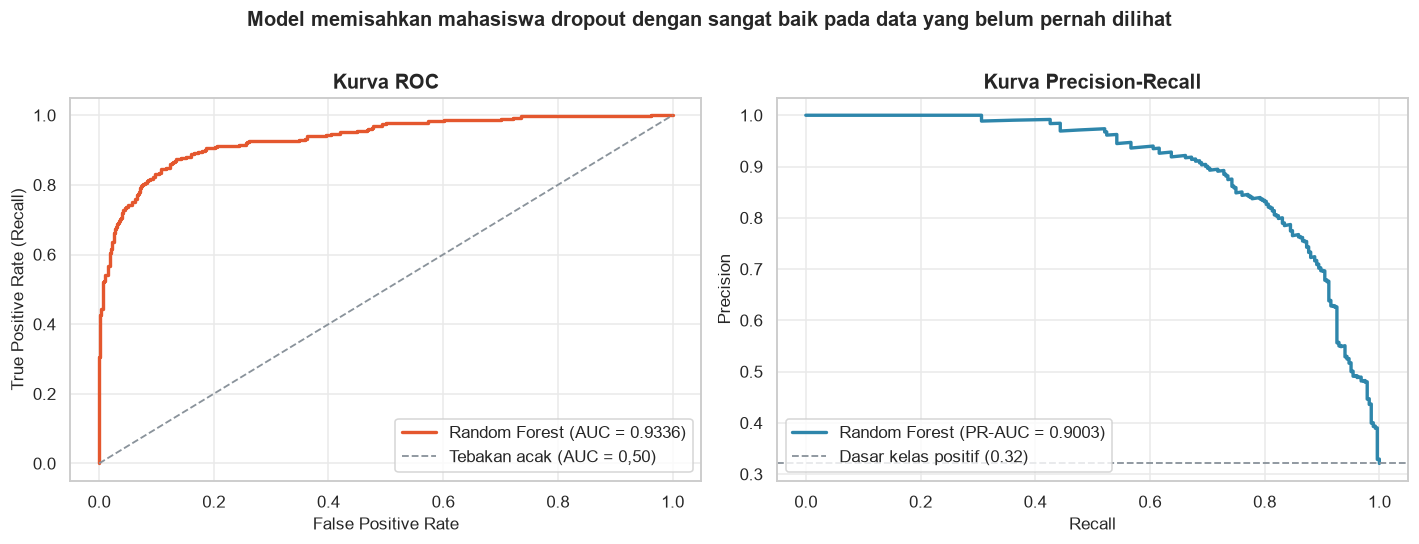

In [15]:
proba_uji = model_terbaik.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, proba_uji):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba_uji):.4f}")
print("\n=== Classification report pada ambang standar 0,50 ===")
print(classification_report(y_test, (proba_uji >= 0.5).astype(int),
                            target_names=["Bukan Dropout", "Dropout"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fpr, tpr, _ = roc_curve(y_test, proba_uji)
axes[0].plot(fpr, tpr, color=DROPOUT, lw=2.2,
             label=f"Random Forest (AUC = {roc_auc_score(y_test, proba_uji):.4f})")
axes[0].plot([0, 1], [0, 1], ls="--", color=GREY, lw=1.2, label="Tebakan acak (AUC = 0,50)")
axes[0].set_title("Kurva ROC"); axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)"); axes[0].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, proba_uji)
axes[1].plot(rec, prec, color=NEUTRAL, lw=2.2,
             label=f"Random Forest (PR-AUC = {average_precision_score(y_test, proba_uji):.4f})")
axes[1].axhline(y_test.mean(), ls="--", color=GREY, lw=1.2,
                label=f"Dasar kelas positif ({y_test.mean():.2f})")
axes[1].set_title("Kurva Precision-Recall"); axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision"); axes[1].legend(loc="lower left")

fig.suptitle("Model memisahkan mahasiswa dropout dengan sangat baik pada data yang belum pernah dilihat",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(ASSETS / "07_kurva_evaluasi.png")
plt.show()

**Insight performa model.** Pada 885 mahasiswa data uji yang belum pernah dilihat model:
**ROC-AUC 0,9336** dan **PR-AUC 0,9003** (dibanding garis dasar kelas positif 0,32). Artinya,
bila diambil satu mahasiswa dropout dan satu mahasiswa non-dropout secara acak, model memberi
skor lebih tinggi kepada yang benar-benar dropout pada **93 dari 100 kasus**.

Pada ambang standar 0,50 model mencapai akurasi 0,878 dengan precision 0,801 dan recall 0,824.
Recall 0,824 berarti **17,6% mahasiswa dropout masih lolos tanpa terdeteksi** — untuk kasus ini
angka tersebut belum cukup baik, sehingga ambang perlu disesuaikan.

 Ambang  Precision  Recall     F1     F2  Akurasi  Ditandai
   0.20     0.5644  0.9261 0.7013 0.8208   0.7469       466
   0.25     0.6247  0.9261 0.7461 0.8446   0.7977       421
   0.30     0.6762  0.9120 0.7766 0.8525   0.8316       383
   0.35     0.7095  0.8944 0.7913 0.8501   0.8486       358
   0.40     0.7389  0.8768 0.8019 0.8452   0.8610       337
   0.45     0.7666  0.8556 0.8087 0.8362   0.8701       317
   0.50     0.8014  0.8239 0.8125 0.8193   0.8780       292
   0.55     0.8208  0.8063 0.8135 0.8092   0.8814       279
   0.60     0.8456  0.7711 0.8066 0.7849   0.8814       259
   0.65     0.8819  0.7359 0.8023 0.7611   0.8836       237
   0.70     0.9032  0.6901 0.7824 0.7243   0.8768       217

Ambang operasional terpilih (F2 maksimum): 0.30


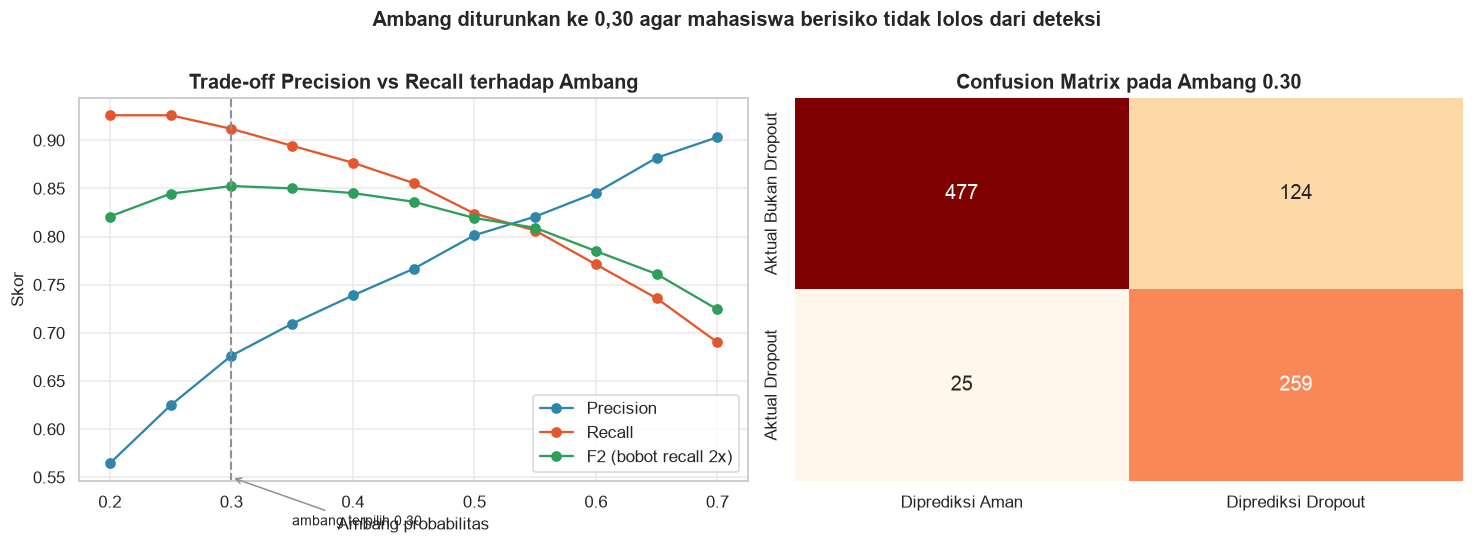


=== Classification report pada ambang operasional ===
               precision    recall  f1-score   support

Bukan Dropout     0.9502    0.7937    0.8649       601
      Dropout     0.6762    0.9120    0.7766       284

     accuracy                         0.8316       885
    macro avg     0.8132    0.8528    0.8208       885
 weighted avg     0.8623    0.8316    0.8366       885



In [16]:
ambang_uji = np.arange(0.20, 0.75, 0.05)
sweep = pd.DataFrame([{
    "Ambang": round(t, 2),
    "Precision": precision_score(y_test, (proba_uji >= t).astype(int)),
    "Recall": recall_score(y_test, (proba_uji >= t).astype(int)),
    "F1": f1_score(y_test, (proba_uji >= t).astype(int)),
    "F2": fbeta_score(y_test, (proba_uji >= t).astype(int), beta=2),
    "Akurasi": accuracy_score(y_test, (proba_uji >= t).astype(int)),
    "Ditandai": int((proba_uji >= t).sum()),
} for t in ambang_uji])

AMBANG = float(sweep.loc[sweep["F2"].idxmax(), "Ambang"])
print(sweep.round(4).to_string(index=False))
print(f"\nAmbang operasional terpilih (F2 maksimum): {AMBANG:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].plot(sweep["Ambang"], sweep["Precision"], marker="o", color=NEUTRAL, label="Precision")
axes[0].plot(sweep["Ambang"], sweep["Recall"], marker="o", color=DROPOUT, label="Recall")
axes[0].plot(sweep["Ambang"], sweep["F2"], marker="o", color=SAFE, label="F2 (bobot recall 2x)")
axes[0].axvline(AMBANG, ls="--", color=GREY, lw=1.4)
axes[0].annotate(f"ambang terpilih {AMBANG:.2f}", (AMBANG, 0.55), xytext=(AMBANG + 0.05, 0.5),
                 fontsize=9, arrowprops={"arrowstyle": "->", "color": GREY})
axes[0].set_title("Trade-off Precision vs Recall terhadap Ambang")
axes[0].set_xlabel("Ambang probabilitas"); axes[0].set_ylabel("Skor"); axes[0].legend()

cm = confusion_matrix(y_test, (proba_uji >= AMBANG).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap="OrRd", cbar=False, ax=axes[1],
            xticklabels=["Diprediksi Aman", "Diprediksi Dropout"],
            yticklabels=["Aktual Bukan Dropout", "Aktual Dropout"], annot_kws={"fontsize": 13})
axes[1].set_title(f"Confusion Matrix pada Ambang {AMBANG:.2f}")

fig.suptitle("Ambang diturunkan ke 0,30 agar mahasiswa berisiko tidak lolos dari deteksi",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(ASSETS / "08_ambang_operasional.png")
plt.show()

print("\n=== Classification report pada ambang operasional ===")
print(classification_report(y_test, (proba_uji >= AMBANG).astype(int),
                            target_names=["Bukan Dropout", "Dropout"], digits=4))

**Insight pemilihan ambang — keputusan bisnis, bukan keputusan statistik.**

Dua jenis kesalahan tidak memiliki biaya yang sama:

| Kesalahan | Konsekuensi | Biaya |
|---|---|---|
| **False negative** — mahasiswa berisiko tidak terdeteksi | Mahasiswa dropout tanpa pernah mendapat bimbingan; institut kehilangan pendapatan sisa masa studi | **Tinggi** |
| **False positive** — mahasiswa aman ikut ditandai | Satu sesi konseling yang sebenarnya tidak diperlukan | **Rendah** |

Karena itu ambang dipilih dengan memaksimalkan **F2-score** (memberi bobot recall dua kali
lipat precision), dan hasilnya adalah **ambang 0,30**. Perbandingannya:

| Ambang | Precision | Recall | F2 | Dropout yang lolos |
|---|---|---|---|---|
| 0,50 (standar) | 0,801 | 0,824 | 0,819 | 50 dari 284 |
| **0,30 (terpilih)** | **0,676** | **0,912** | **0,853** | **25 dari 284** |

Menurunkan ambang menaikkan recall dari 82,4% ke **91,2%** — jumlah mahasiswa dropout yang lolos
**turun setengahnya, dari 50 menjadi 25 orang**. Ongkosnya: 383 mahasiswa ditandai (bukan 292),
dan sekitar 1 dari 3 yang ditandai sebenarnya aman. Untuk unit bimbingan konseling, memanggil
124 mahasiswa tambahan jauh lebih murah daripada kehilangan 25 mahasiswa.

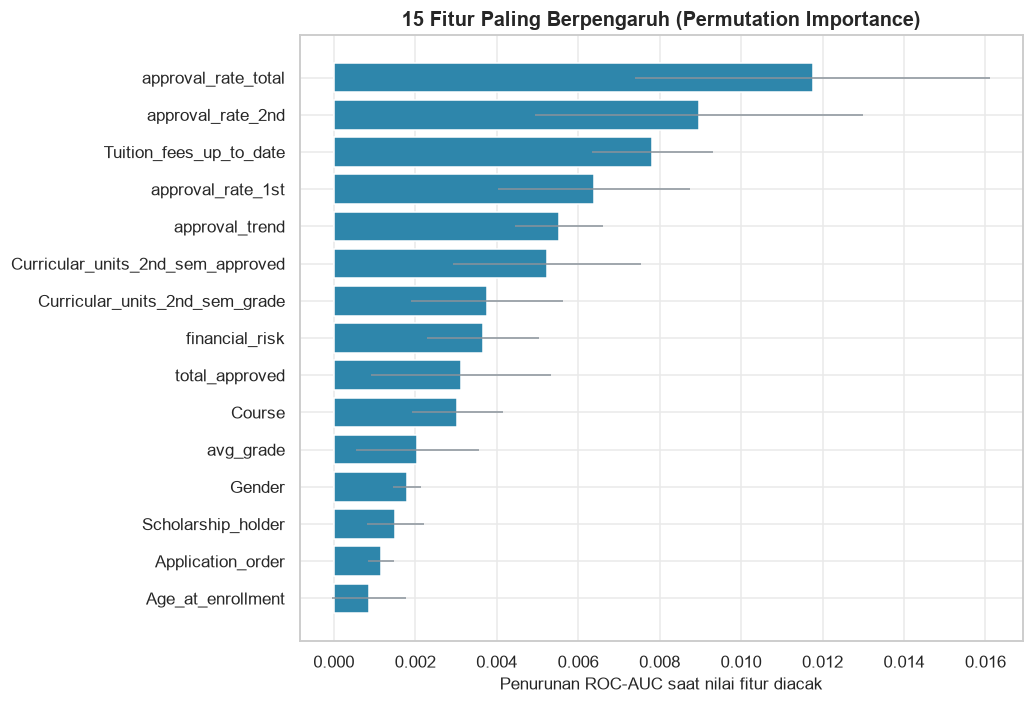

                            fitur  importance     std
              approval_rate_total     0.01175 0.00436
                approval_rate_2nd     0.00897 0.00403
          Tuition_fees_up_to_date     0.00782 0.00148
                approval_rate_1st     0.00639 0.00236
                   approval_trend     0.00552 0.00108
Curricular_units_2nd_sem_approved     0.00523 0.00230
   Curricular_units_2nd_sem_grade     0.00376 0.00187
                   financial_risk     0.00367 0.00137
                   total_approved     0.00311 0.00221
                           Course     0.00303 0.00112


In [17]:
hasil_perm = permutation_importance(model_terbaik, X_test, y_test, n_repeats=15,
                                    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
importance = (pd.DataFrame({"fitur": X_test.columns,
                            "importance": hasil_perm.importances_mean,
                            "std": hasil_perm.importances_std})
              .sort_values("importance", ascending=False).reset_index(drop=True))

top15 = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.barh(top15["fitur"], top15["importance"], xerr=top15["std"],
        color=NEUTRAL, error_kw={"ecolor": GREY, "lw": 1})
ax.set_title("15 Fitur Paling Berpengaruh (Permutation Importance)")
ax.set_xlabel("Penurunan ROC-AUC saat nilai fitur diacak")
fig.tight_layout()
fig.savefig(ASSETS / "09_feature_importance.png")
plt.show()

print(importance.head(10).round(5).to_string(index=False))

**Insight faktor penentu dropout.** *Permutation importance* mengukur seberapa jauh ROC-AUC
turun ketika nilai satu fitur diacak — semakin besar penurunannya, semakin bergantung model
pada fitur tersebut. Sepuluh besarnya:

| # | Fitur | Penurunan ROC-AUC | Kelompok |
|---|---|---|---|
| 1 | `approval_rate_total` | 0,0118 | Akademik |
| 2 | `approval_rate_2nd` | 0,0090 | Akademik |
| 3 | `Tuition_fees_up_to_date` | 0,0078 | **Keuangan** |
| 4 | `approval_rate_1st` | 0,0064 | Akademik |
| 5 | `approval_trend` | 0,0055 | Akademik |
| 6 | `Curricular_units_2nd_sem_approved` | 0,0052 | Akademik |
| 7 | `Curricular_units_2nd_sem_grade` | 0,0038 | Akademik |
| 8 | `financial_risk` | 0,0037 | **Keuangan** |
| 9 | `total_approved` | 0,0031 | Akademik |
| 10 | `Course` | 0,0030 | Program studi |

Tiga kesimpulan:

1. **Enam dari sepuluh fitur teratas adalah fitur hasil rekayasa** (`approval_rate_*`,
   `approval_trend`, `financial_risk`). Feature engineering memberi kontribusi nyata, bukan
   sekadar formalitas.
2. **Rasio kelulusan mata kuliah mendominasi**, dan `approval_trend` masuk 5 besar — artinya
   model tidak hanya melihat posisi mahasiswa, tetapi juga **arah perubahannya**. Mahasiswa yang
   memburuk dari semester 1 ke semester 2 lebih berisiko daripada yang stabil di level sama.
3. **Status kelunasan UKT adalah satu-satunya fitur non-akademik di 3 besar.** Kondisi keuangan
   berdiri sendiri sebagai penyebab, bukan sekadar gejala performa akademik yang buruk.

ROC-AUC out-of-fold seluruh 4.424 mahasiswa: 0.9208
PR-AUC  out-of-fold                        : 0.8746

=== Kalibrasi band risiko ===
               Jumlah Mahasiswa  Dropout Aktual (%)
Rendah                     2105                 4.8
Sedang                      534                14.0
Tinggi                      542                36.3
Sangat Tinggi              1243                84.2


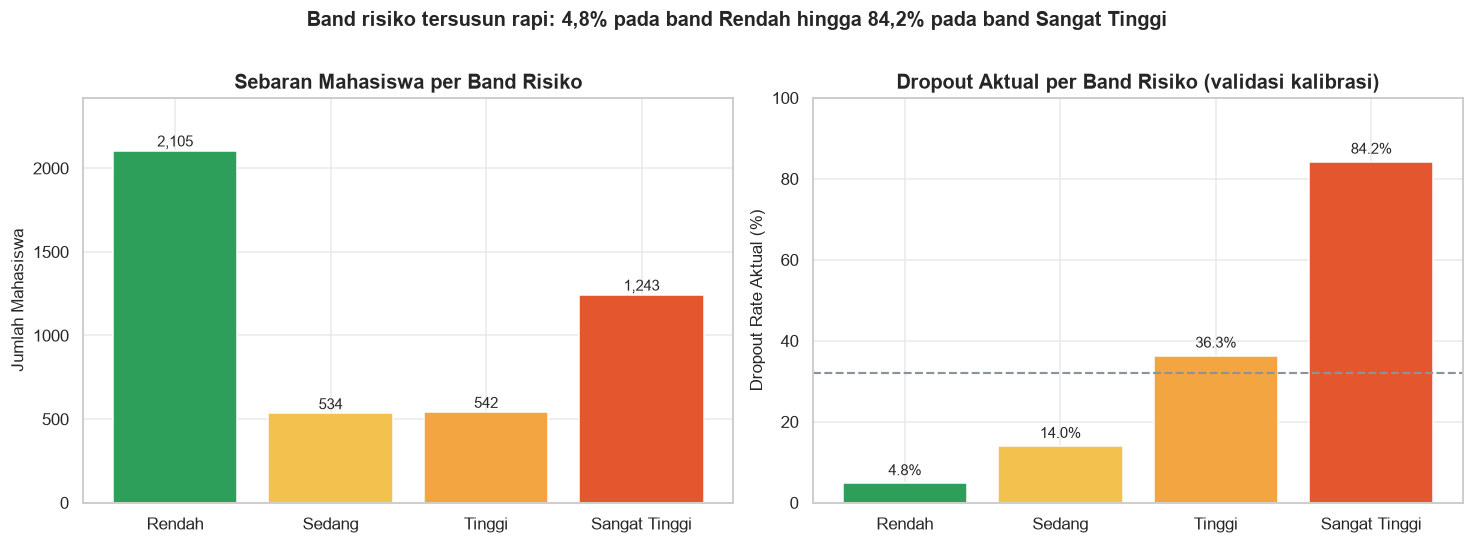

In [18]:
# Skor risiko out-of-fold: setiap mahasiswa dinilai oleh model yang tidak pernah melihat
# datanya, sehingga angka pada dashboard tidak terlalu optimistis (bebas bias in-sample).
pipeline_final = clone(model_terbaik)
risiko_oof = cross_val_predict(pipeline_final, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

print(f"ROC-AUC out-of-fold seluruh 4.424 mahasiswa: {roc_auc_score(y, risiko_oof):.4f}")
print(f"PR-AUC  out-of-fold                        : {average_precision_score(y, risiko_oof):.4f}")

band = pd.Series([pp.risk_band(v) for v in risiko_oof], index=X.index)
urut_band = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
kalibrasi = pd.DataFrame({
    "Jumlah Mahasiswa": band.value_counts().reindex(urut_band),
    "Dropout Aktual (%)": (y.groupby(band).mean() * 100).reindex(urut_band).round(1),
})
print("\n=== Kalibrasi band risiko ===")
print(kalibrasi.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
warna_band = ["#2E9E5B", "#F2C14E", "#F2A541", "#E4572E"]
axes[0].bar(urut_band, kalibrasi["Jumlah Mahasiswa"], color=warna_band)
for x, v in enumerate(kalibrasi["Jumlah Mahasiswa"]):
    axes[0].text(x, v + 25, f"{int(v):,}", ha="center", fontsize=10)
axes[0].set_title("Sebaran Mahasiswa per Band Risiko"); axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].set_ylim(0, kalibrasi["Jumlah Mahasiswa"].max() * 1.15)

axes[1].bar(urut_band, kalibrasi["Dropout Aktual (%)"], color=warna_band)
axes[1].axhline(BASELINE, ls="--", color=GREY, lw=1.4)
for x, v in enumerate(kalibrasi["Dropout Aktual (%)"]):
    axes[1].text(x, v + 2, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_title("Dropout Aktual per Band Risiko (validasi kalibrasi)")
axes[1].set_ylabel("Dropout Rate Aktual (%)"); axes[1].set_ylim(0, 100)

fig.suptitle("Band risiko tersusun rapi: 4,8% pada band Rendah hingga 84,2% pada band Sangat Tinggi",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(ASSETS / "10_band_risiko.png")
plt.show()

**Insight kalibrasi band risiko.** Skor probabilitas diringkas menjadi empat band agar dapat
dipakai staf akademik tanpa perlu menafsirkan angka desimal: **Rendah (<0,20), Sedang (0,20-0,35),
Tinggi (0,35-0,60), Sangat Tinggi (≥0,60)**.

Pengujian silang membuktikan band ini **terkalibrasi dengan baik**:

| Band | Jumlah Mahasiswa | Dropout Aktual |
|---|---|---|
| Rendah | 2.105 | **4,8%** |
| Sedang | 534 | 14,0% |
| Tinggi | 542 | 36,3% |
| Sangat Tinggi | 1.243 | **84,2%** |

Kenaikannya monoton dan jaraknya lebar — dari 4,8% ke 84,2%, atau **17,5 kali lipat**. Dengan
begitu label band bisa langsung dipercaya sebagai prioritas kerja: mahasiswa band Sangat Tinggi
memang benar-benar hampir pasti dropout bila dibiarkan, sementara band Rendah aman untuk tidak
diprioritaskan. ROC-AUC out-of-fold **0,9208** pada seluruh 4.424 mahasiswa juga mengonfirmasi
bahwa performa 0,9336 pada data uji bukan kebetulan pembagian data.

## Deployment

Tahap terakhir mengemas hasil analisis menjadi artefak yang dapat langsung dipakai:

1. **`model/dropout_model.joblib`** — pipeline lengkap (preprocessing + Random Forest terlatih)
   yang dilatih ulang pada **seluruh 4.424 baris**, dipakai aplikasi Streamlit.
2. **`model/model_metadata.json`** — kontrak model: daftar fitur, ambang operasional, metrik
   evaluasi, dan definisi band risiko, sehingga aplikasi tidak perlu menebak-nebak.
3. **`data/students_scored.csv`** — tabel analitik berisi seluruh mahasiswa dengan label
   terbaca, skor risiko, dan band risiko; menjadi sumber data business dashboard Metabase.
4. **`data/feature_importance.csv`** — faktor penentu untuk panel dashboard.
5. **`data/watchlist_enrolled.csv`** — daftar prioritas 794 mahasiswa yang masih aktif kuliah,
   terurut dari risiko tertinggi. Inilah keluaran yang paling langsung dipakai institut.

In [19]:
# --- 1. Latih ulang model terpilih pada seluruh data --------------------------------
model_final = clone(model_terbaik).fit(X, y)
# compress=3 menekan ukuran berkas dari ~40 MB menjadi ~10 MB tanpa mengubah model,
# penting agar aplikasi ringan saat di-deploy ke Streamlit Community Cloud.
joblib.dump(model_final, MODEL_DIR / "dropout_model.joblib", compress=3)

metadata = {
    "nama_model": nama_terbaik,
    "algoritma": type(model_final.named_steps["clf"]).__name__,
    "target": "Status == 'Dropout' (klasifikasi biner)",
    "jumlah_data_latih": int(len(X)),
    "proporsi_kelas_positif": round(float(y.mean()), 4),
    "ambang_operasional": AMBANG,
    "alasan_ambang": "Memaksimalkan F2-score; biaya false negative jauh lebih tinggi "
                     "daripada false positive pada kasus retensi mahasiswa.",
    "fitur_kategorikal": pp.CATEGORICAL_FEATURES,
    "fitur_numerik": pp.NUMERIC_FEATURES,
    "kolom_input_mentah": pp.RAW_INPUT_COLUMNS,
    "hyperparameter": {k.replace("clf__", ""): (v if isinstance(v, (int, float, str, type(None))) else str(v))
                       for k, v in model_final.named_steps["clf"].get_params().items()
                       if k in {"n_estimators", "max_depth", "max_features",
                                "min_samples_leaf", "min_samples_split", "class_weight"}},
    "metrik_data_uji": {
        "roc_auc": round(float(roc_auc_score(y_test, proba_uji)), 4),
        "pr_auc": round(float(average_precision_score(y_test, proba_uji)), 4),
        "akurasi_ambang_operasional": round(float(accuracy_score(y_test, (proba_uji >= AMBANG).astype(int))), 4),
        "precision_ambang_operasional": round(float(precision_score(y_test, (proba_uji >= AMBANG).astype(int))), 4),
        "recall_ambang_operasional": round(float(recall_score(y_test, (proba_uji >= AMBANG).astype(int))), 4),
        "f2_ambang_operasional": round(float(fbeta_score(y_test, (proba_uji >= AMBANG).astype(int), beta=2)), 4),
    },
    "roc_auc_out_of_fold": round(float(roc_auc_score(y, risiko_oof)), 4),
    "band_risiko": [{"band": b, "batas_bawah": lo, "batas_atas": hi} for lo, hi, b in pp.RISK_BANDS],
    "versi_scikit_learn": sklearn.__version__,
}
(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Model disimpan  : {MODEL_DIR / 'dropout_model.joblib'} "
      f"({(MODEL_DIR / 'dropout_model.joblib').stat().st_size / 1024:.0f} KB)")
print(f"Metadata        : {MODEL_DIR / 'model_metadata.json'}")
print(json.dumps(metadata["metrik_data_uji"], indent=2))

Model disimpan  : model/dropout_model.joblib (9553 KB)
Metadata        : model/model_metadata.json
{
  "roc_auc": 0.9336,
  "pr_auc": 0.9003,
  "akurasi_ambang_operasional": 0.8316,
  "precision_ambang_operasional": 0.6762,
  "recall_ambang_operasional": 0.912,
  "f2_ambang_operasional": 0.8525
}


In [20]:
# --- 2. Tabel analitik untuk business dashboard -------------------------------------
scored = pp.add_readable_labels(pp.engineer_features(df)).copy()
scored.insert(0, "student_id", [f"JJI-{i:05d}" for i in range(1, len(scored) + 1)])
scored["dropout_probability"] = risiko_oof.round(4)
scored["risk_score"] = (risiko_oof * 100).round(1)
scored["risk_band"] = [pp.risk_band(v) for v in risiko_oof]
scored["is_dropout"] = (scored["Status"] == pp.POSITIVE_CLASS).astype(int)
scored["is_flagged"] = (risiko_oof >= AMBANG).astype(int)

kolom_dashboard = {
    "student_id": "student_id", "Status": "status", "is_dropout": "is_dropout",
    "risk_score": "risk_score", "risk_band": "risk_band", "is_flagged": "is_flagged",
    "program_studi": "program_studi", "jalur_masuk": "jalur_masuk",
    "jalur_masuk_detail": "jalur_masuk_detail", "waktu_kuliah": "waktu_kuliah",
    "jenis_kelamin": "jenis_kelamin", "status_pernikahan": "status_pernikahan",
    "kelompok_usia": "kelompok_usia", "Age_at_enrollment": "usia_saat_daftar",
    "band_nilai_masuk": "band_nilai_masuk", "Admission_grade": "nilai_masuk",
    "status_keuangan": "status_keuangan",
    "tuition_fees_up_to_date_label": "ukt_lunas", "debtor_label": "menunggak",
    "scholarship_holder_label": "penerima_beasiswa", "displaced_label": "perantau",
    "international_label": "mahasiswa_internasional",
    "band_kelulusan_sks": "band_kelulusan_sks", "band_nilai_semester": "band_nilai_semester",
    "approval_rate_total": "rasio_kelulusan", "avg_grade": "rata_rata_nilai",
    "approval_trend": "tren_kelulusan", "total_approved": "total_mk_lulus",
    "Curricular_units_1st_sem_approved": "mk_lulus_sem1",
    "Curricular_units_2nd_sem_approved": "mk_lulus_sem2",
    "Curricular_units_1st_sem_grade": "nilai_sem1",
    "Curricular_units_2nd_sem_grade": "nilai_sem2",
}
tabel_dashboard = scored[list(kolom_dashboard)].rename(columns=kolom_dashboard).round(4)
tabel_dashboard.to_csv(DATA_DIR / "students_scored.csv", index=False)

importance.rename(columns={"fitur": "fitur", "importance": "importance", "std": "std_dev"}) \
          .round(6).to_csv(DATA_DIR / "feature_importance.csv", index=False)

watchlist = (tabel_dashboard[tabel_dashboard["status"] == "Enrolled"]
             .sort_values("risk_score", ascending=False)
             .loc[:, ["student_id", "program_studi", "jalur_masuk", "kelompok_usia",
                      "status_keuangan", "ukt_lunas", "menunggak", "penerima_beasiswa",
                      "rasio_kelulusan", "rata_rata_nilai", "tren_kelulusan",
                      "risk_score", "risk_band"]])
watchlist.to_csv(DATA_DIR / "watchlist_enrolled.csv", index=False)

print(f"students_scored.csv    : {tabel_dashboard.shape[0]:,} baris x {tabel_dashboard.shape[1]} kolom")
print(f"feature_importance.csv : {len(importance)} baris")
print(f"watchlist_enrolled.csv : {len(watchlist):,} mahasiswa aktif\n")
print("=== Sebaran band risiko mahasiswa yang masih aktif kuliah (Enrolled) ===")
print(watchlist["risk_band"].value_counts().reindex(urut_band).to_string())
print(f"\nDitandai untuk intervensi (risiko >= {AMBANG:.0%}): "
      f"{int((watchlist['risk_score'] >= AMBANG * 100).sum()):,} dari {len(watchlist):,} mahasiswa aktif")
watchlist.head(10)

students_scored.csv    : 4,424 baris x 32 kolom
feature_importance.csv : 29 baris
watchlist_enrolled.csv : 794 mahasiswa aktif

=== Sebaran band risiko mahasiswa yang masih aktif kuliah (Enrolled) ===
risk_band
Rendah           222
Sedang           180
Tinggi           224
Sangat Tinggi    168

Ditandai untuk intervensi (risiko >= 30%): 446 dari 794 mahasiswa aktif


,student_id,program_studi,jalur_masuk,kelompok_usia,status_keuangan,ukt_lunas,menunggak,penerima_beasiswa,rasio_kelulusan,rata_rata_nilai,tren_kelulusan,risk_score,risk_band
1987,JJI-01988,Manajemen (kelas malam),Jalur Usia >23 Tahun,31-40,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.00,0.000,0.0,98.6,Sangat Tinggi
942,JJI-00943,Pekerjaan Sosial,Jalur Usia >23 Tahun,31-40,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.00,0.000,0.0,98.3,Sangat Tinggi
2794,JJI-02795,Manajemen (kelas malam),Jalur Usia >23 Tahun,26-30,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.00,0.000,0.0,98.1,Sangat Tinggi
2704,JJI-02705,Manajemen Periklanan & Pemasaran,Seleksi Reguler,17-19,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.00,0.000,0.0,97.8,Sangat Tinggi
3077,JJI-03078,Teknik Informatika,Pindahan / Ganti Program,26-30,Bermasalah (menunggak & UKT tertunggak),Tidak,Ya,Tidak,0.00,0.000,0.0,97.8,Sangat Tinggi
3499,JJI-03500,Agronomi,Jalur Usia >23 Tahun,26-30,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.00,0.000,0.0,97.7,Sangat Tinggi
64,JJI-00065,Desain Komunikasi,Pindahan / Ganti Program,23-25,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.00,0.000,0.0,97.5,Sangat Tinggi
358,JJI-00359,Agronomi,Jalur Usia >23 Tahun,26-30,Perlu perhatian (1 masalah),Ya,Ya,Ya,0.00,0.000,0.0,97.5,Sangat Tinggi
4281,JJI-04282,Keperawatan Hewan,Seleksi Reguler,20-22,Aman (lunas & tidak menunggak),Ya,Tidak,Tidak,0.25,5.625,-0.5,97.0,Sangat Tinggi
2239,JJI-02240,Keperawatan Hewan,Jalur Usia >23 Tahun,23-25,Bermasalah (menunggak & UKT tertunggak),Tidak,Ya,Tidak,0.00,0.000,0.0,97.0,Sangat Tinggi


**Insight daftar prioritas.** Dari **794 mahasiswa yang masih aktif kuliah**, model menandai
**446 mahasiswa (56%)** berada di atas ambang intervensi — terdiri atas **168 mahasiswa band
Sangat Tinggi** dan **224 band Tinggi**. Berdasarkan kalibrasi sebelumnya, kelompok Sangat Tinggi
memiliki probabilitas dropout aktual ± 84%; **bila tidak diintervensi, sekitar 141 dari 168
mahasiswa tersebut akan berhenti kuliah**.

Angka ini yang membuat proyek bernilai bisnis: institut kini punya **daftar nama konkret dengan
urutan prioritas**, bukan sekadar statistik agregat. Unit bimbingan dapat memulai dari 168
mahasiswa band Sangat Tinggi minggu ini juga, alih-alih menunggu laporan akhir semester.

In [21]:
# --- 3. Uji muat ulang: memastikan artefak benar-benar dapat dipakai aplikasi -------
model_dimuat = joblib.load(MODEL_DIR / "dropout_model.joblib")
meta_dimuat = json.loads((MODEL_DIR / "model_metadata.json").read_text(encoding="utf-8"))

contoh_mahasiswa = pd.DataFrame([{
    "Marital_status": 1, "Application_mode": 39, "Application_order": 1, "Course": 9119,
    "Daytime_evening_attendance": 1, "Previous_qualification_grade": 120.0,
    "Admission_grade": 118.0, "Displaced": 0, "Debtor": 1, "Tuition_fees_up_to_date": 0,
    "Gender": 1, "Scholarship_holder": 0, "Age_at_enrollment": 28, "International": 0,
    "Curricular_units_1st_sem_enrolled": 6, "Curricular_units_1st_sem_approved": 2,
    "Curricular_units_1st_sem_grade": 10.5, "Curricular_units_2nd_sem_enrolled": 6,
    "Curricular_units_2nd_sem_approved": 1, "Curricular_units_2nd_sem_grade": 8.0,
}])

fitur_contoh = pp.prepare_for_model(contoh_mahasiswa)
peluang = float(model_dimuat.predict_proba(fitur_contoh)[0, 1])

print("Contoh: mahasiswa Teknik Informatika, 28 tahun, menunggak UKT, hanya lulus 3 dari 12 mata kuliah")
print(f"   Probabilitas dropout : {peluang:.1%}")
print(f"   Band risiko          : {pp.risk_band(peluang)}")
print(f"   Ambang institut      : {meta_dimuat['ambang_operasional']:.0%} "
      f"-> {'PERLU INTERVENSI' if peluang >= meta_dimuat['ambang_operasional'] else 'aman'}")

Contoh: mahasiswa Teknik Informatika, 28 tahun, menunggak UKT, hanya lulus 3 dari 12 mata kuliah
   Probabilitas dropout : 94.2%
   Band risiko          : Sangat Tinggi
   Ambang institut      : 30% -> PERLU INTERVENSI


**Penjelasan tahapan.** Artefak diuji muat ulang dari berkas (bukan dari memori notebook)
lalu dipakai memprediksi satu mahasiswa contoh. Pipeline menerima **20 kolom mentah**,
menjalankan feature engineering yang sama seperti saat pelatihan, dan mengembalikan probabilitas
dropout. Uji ini memastikan tidak ada ketergantungan tersembunyi pada state notebook — dasar
yang membuat aplikasi Streamlit dan dashboard Metabase berjalan konsisten.

## Conclusion

**Jaya Jaya Institut kehilangan 32,12% mahasiswanya (1.421 dari 4.424) karena dropout, dan
proyek ini membuktikan bahwa mayoritas kasus tersebut dapat diprediksi jauh sebelum terjadi.**
Model Random Forest yang dibangun mencapai **ROC-AUC 0,9336** pada data uji dan berhasil
menangkap **91,2% mahasiswa dropout** pada ambang operasional 0,30.

**Jawaban atas permasalahan bisnis yang diajukan institut:**

**1. Apa penyebab utama dropout?** Ada dua akar masalah yang berdiri sendiri:

- **Kondisi keuangan.** Mahasiswa yang UKT-nya belum lunas dropout **86,55%** berbanding 24,74%
  pada yang lunas — selisih 3,5 kali lipat dan merupakan pemisah tunggal paling tajam di seluruh
  dataset. Status debtor menghasilkan pola serupa (62,03% vs 28,28%), sementara beasiswa terbukti
  protektif (12,19% vs 38,71%). `Tuition_fees_up_to_date` juga menempati posisi **ketiga** pada
  permutation importance model.
- **Keterlibatan akademik tahun pertama.** Mahasiswa yang tidak lulus satu pun mata kuliah
  dropout **80,77%**, sementara yang lulus 81-100% mata kuliah hanya **7,70%**. Rasio kelulusan
  mata kuliah (`approval_rate_total`, `approval_rate_2nd`) menempati dua posisi teratas pada
  permutation importance. Semester kedua lebih prediktif daripada semester pertama
  (korelasi -0,66 vs -0,59).

**2. Siapa yang paling rentan?** Profil risiko tinggi terbentuk konsisten di beberapa dimensi:
mahasiswa **berusia 26-30 tahun (dropout 59,79%)**, **laki-laki (45,05%)**, **kelas malam
(42,86%)**, **masuk lewat jalur usia di atas 23 tahun (55,41%)** atau **pemegang ijazah lain
(61,15%)**, dan terdaftar pada program studi **Pengelolaan Kuda (55,32%)**, **Teknik Informatika
(54,12%)**, atau **Manajemen kelas malam (50,75%)**. Sebaliknya, Keperawatan — program studi
terbesar dengan 766 mahasiswa — hanya dropout 15,40%. **Masalah dropout tidak merata**, sehingga
intervensi paling efisien bila difokuskan pada segmen-segmen ini.

**3. Bisakah dropout dideteksi lebih awal?** Bisa, dan akurasinya tinggi. Model hanya memerlukan
data yang **sudah dimiliki institut pada akhir tahun pertama** — tidak ada survei atau
pengumpulan data baru yang diperlukan. Band risiko terbukti terkalibrasi rapi: **4,8% dropout
aktual pada band Rendah hingga 84,2% pada band Sangat Tinggi**, selisih 17,5 kali lipat, sehingga
label band dapat langsung dipercaya sebagai urutan prioritas kerja.

**4. Bagaimana institut memonitornya?** Dua alat sudah tersedia dan siap dipakai:
**business dashboard Metabase** (22 kartu visualisasi di atas PostgreSQL) untuk memantau tren
per program studi, jalur masuk, dan status keuangan; serta **prototipe Streamlit** yang di-deploy
di Streamlit Community Cloud untuk memprediksi risiko satu mahasiswa maupun satu angkatan
sekaligus melalui unggahan CSV.

**5. Apa hasil konkretnya sekarang?** Dari 794 mahasiswa yang masih aktif kuliah, **446 mahasiswa
ditandai perlu intervensi**, dengan **168 di antaranya berada di band Sangat Tinggi**. Bila pola
historis berulang, sekitar **141 dari 168 mahasiswa tersebut akan dropout tanpa intervensi**.
Daftar nama lengkapnya sudah tersedia di `data/watchlist_enrolled.csv` dan pada panel terakhir
dashboard.

### Rekomendasi Action Items

Lima tindakan berikut disusun berdasarkan bukti kuantitatif di atas dan diurutkan dari yang
dampaknya paling besar.

- **1. Jadikan tunggakan UKT sebagai alarm dropout, bukan sekadar urusan administrasi.**
  Terapkan aturan: setiap mahasiswa yang UKT-nya lewat jatuh tempo **lebih dari 30 hari otomatis
  dirujuk ke unit bimbingan**, bukan hanya menerima surat tagihan. Dasarnya: 86,55% mahasiswa
  dalam kondisi ini berakhir dropout. Sediakan opsi cicilan, penundaan, atau beasiswa darurat —
  data menunjukkan penerima beasiswa hanya dropout 12,19%, sepertiga dari non-penerima.
  Memperluas beasiswa ke mahasiswa berisiko tinggi berpotensi menekan dropout paling besar per
  rupiah yang dikeluarkan.

- **2. Pasang sistem peringatan dini berbasis mata kuliah pada minggu ke-6 setiap semester.**
  Mahasiswa yang **tidak lulus satu pun mata kuliah dropout 80,77%**, dan 676 mahasiswa berada
  dalam kondisi ini. Jangan menunggu nilai akhir semester: pantau kehadiran dan hasil evaluasi
  tengah semester, lalu wajibkan sesi konseling akademik bagi mahasiswa dengan rasio kelulusan
  di bawah 50%. Prioritaskan pula mahasiswa dengan `approval_trend` negatif (performa memburuk
  dari semester 1 ke semester 2) — fitur ini masuk 5 besar penentu model.

- **3. Kerjakan daftar prioritas 168 mahasiswa band Sangat Tinggi semester ini juga.**
  Gunakan `data/watchlist_enrolled.csv` atau panel "Daftar Prioritas Intervensi" pada dashboard.
  Tetapkan satu dosen wali sebagai penanggung jawab per mahasiswa, dengan target kontak maksimal
  2 minggu dan pencatatan hasil intervensi. Pencatatan ini penting: ia menjadi data pelatihan
  putaran berikutnya untuk mengukur **program bimbingan mana yang benar-benar bekerja**.

- **4. Bentuk program pendampingan khusus untuk mahasiswa non-tradisional.**
  Mahasiswa jalur usia di atas 23 tahun (dropout 55,41%, 785 orang), kelas malam (42,86%), dan
  yang sudah menikah (47,23%) memiliki pola risiko yang sama: **kuliah bersaing dengan pekerjaan
  dan tanggung jawab keluarga**. Solusinya bukan bimbingan akademik biasa, melainkan fleksibilitas
  — kelas daring/rekaman, batas SKS yang lebih rendah pada tahun pertama, dan orientasi khusus
  manajemen waktu di awal semester.

- **5. Lakukan audit kurikulum pada tiga program studi dengan dropout tertinggi.**
  Teknik Informatika (54,12%), Pengelolaan Kuda (55,32%), dan Manajemen kelas malam (50,75%)
  memiliki dropout **lebih dari tiga kali lipat** Keperawatan (15,40%). Selisih sebesar ini tidak
  bisa dijelaskan oleh profil mahasiswa saja. Periksa beban SKS tahun pertama, tingkat kelulusan
  per mata kuliah, dan kualitas pembimbingan akademik pada ketiga program studi tersebut —
  lalu pelajari apa yang membuat Keperawatan berhasil dan replikasikan.

**Cara mengukur keberhasilan.** Pantau tiga indikator pada dashboard setiap akhir semester:
(1) dropout rate keseluruhan dengan **target turun dari 32,12% menjadi di bawah 25% dalam dua
tahun**, (2) jumlah mahasiswa band Sangat Tinggi yang berhasil bertahan setelah diintervensi,
dan (3) dropout rate pada tiga program studi prioritas. Model perlu **dilatih ulang setiap akhir
tahun akademik** menggunakan data angkatan terbaru agar tetap relevan.